In [1]:
import accelforge as af
from scheduling.scheduler import *
from af_wrapper import *
import numpy as np


def run(
    einsums,
    compute_units,
    data_dependencies,
    latency_per_component_grid = None,
    total_latency_grid = None,
    actions_grid = None,
    memory_name = None,
    shared_memory_info = None,
):
    schedule, min_latency = best_schedule(
        einsums,
        compute_units,
        shared_memory_info,
        data_dependencies,
        latency_per_component_grid,
        total_latency_grid,
        actions_grid,
        memory_name
    )
    return schedule, min_latency


In [2]:
arch = "arch/eyeriss-dual-core-identical/full.yaml"
m2_workload = "workload/mem-partition-tests/parallel-mm/full.yaml"

In [83]:
spec = af.Spec.from_yaml(
"arch/eyeriss-dual-core-identical/core1-GlobalBuffer-25.yaml",
    "workload/mem-partition-tests/conv/E0.yaml",
    jinja_parse_data=dict(M=512, N=131072, K=128, X=128, Z=128, Y=512)
)

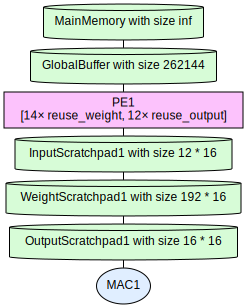

In [84]:
spec.arch

In [ ]:
m2_full_mapping = af_map(
    "arch/eyeriss-dual-core-identical/core2-GlobalBuffer-5.yaml",
    "workload/mem-partition-tests/conv/E0.yaml",
)

Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 1/1 [00:00<00:00,  2.74it/s]
Generating jobs:   0%|          | 0/1 [00:00<?, ?it/s]

Generating pmapping templates for compute MAC2 Einsum T0: 0it [00:00, ?it/s]

Generating pmapping templates for compute MAC2 Einsum T0: 5it [00:00, 39.18it/s]

Generating pmapping templates for compute MAC2 Einsum T0: 11it [00:00, 48.31it/s]

Generating pmapping templates for compute MAC2 Einsum T0: 17it [00:00, 50.07it/s]

Generating pmapping templates for compute MAC2 Einsum T0: 23it [00:00, 47.36it/s]

Generating pmapping templates for compute MAC2 Einsum T0: 28it [00:00, 45.37it/s]

Generating pmapping templates for compute MAC2 Einsum T0: 33it [00:00, 42.89it/s]

Generating pmapping templates for compute MAC2 Einsum T0: 39it [00:00, 45.78it/s]

Generating pmapping templates for compute MAC2 Einsum T0: 45it [00:00, 45.50it/s]

Generating pmapping templates for compute MAC2 Einsum T0: 51it [00:01, 47.82it/

Einsum T0 has 196 pmapping jobs:
	0	[W0 in MainMemory] [T0 in MainMemory] [I0 in MainMemory] T-c0  T-p0  T-q0  T-r0  T-s0  S-reuse_output-s0  S-reuse_output-r0  S-reuse_output-c0  S-reuse_weight-q0  S-reuse_weight-p0  [I0 in InputScratchpad2] T-p0  T-q0  T-r0  T-s0  T-m0  [W0 in WeightScratchpad2] T-p0  T-q0  [T0 in OutputScratchpad2] T-c0  T-r0  T-s0  MAC2 computes T0
	1	[W0 in MainMemory] [T0 in MainMemory] [I0 in MainMemory] T-c0  T-p0  T-q0  T-r0  T-s0  S-reuse_output-s0  S-reuse_output-r0  S-reuse_output-c0  S-reuse_weight-q0  S-reuse_weight-p0  [I0 in InputScratchpad2] T-q0  T-p0  T-r0  T-s0  T-m0  [W0 in WeightScratchpad2] T-p0  T-q0  [T0 in OutputScratchpad2] T-c0  T-r0  T-s0  MAC2 computes T0
	2	[W0 in MainMemory] [T0 in MainMemory] [I0 in MainMemory] T-c0  T-p0  T-q0  T-r0  T-s0  S-reuse_output-s0  S-reuse_output-r0  S-reuse_output-c0  S-reuse_weight-q0  S-reuse_weight-p0  [I0 in InputScratchpad2] T-r0  T-p0  T-q0  T-s0  T-m0  [W0 in WeightScratchpad2] T-p0  T-q0  [T0 in Outp

Generating pmappings:   0%|          | 0/196 [00:00<?, ?it/s]

In [ ]:
mappings = []
for i in range(1):
    filename = "ansa_test"
    with open("images/" + filename + ".svg", "w") as f:
        f.write(m2_full_mapping[i].render())
    mappings.append(process_mapping(arch, m2_workload, m2_full_mapping[i]))


In [ ]:
mapping = mappings[0]['mapping']

mapping.latency(per_component=True)

In [ ]:
data_dependencies = {
    "E0": [],
    "E1": [],
}
compute_units = ['core2', 'core1']
einsums = data_dependencies.keys()
memory_name = "MainMemory"
shared_mem_info = {'GlobalBuffer' : [(0, 100), (100, 0), (10, 90), (5, 95), (25, 75), (75, 25)]}

In [ ]:
from arch.arch_utils import *

arch_pairings = generate_architecture_pairings(compute_units, shared_mem_info)

In [ ]:
%%capture grid_output

# RUN TO GENERATE ACCELFORGE VALUES.
# To skip recomputation when running with fresh kernel, comment out
# this cell and use the below assignments instead.

(grid_lats, grid_mems, grid_maps) = af_memoizable_grid_mem(
    einsums, 
    arch_pairings,
    lambda einsum: "workload/mem-partition-tests/conv/"+einsum+".yaml",
    "arch/eyeriss-dual-core-identical/",
    jinja_parse_data=dict(M=512, N=131072, K=128, X=128, Z=128, Y=512)
)

In [ ]:
grid_lats

In [26]:
grid_mems

{(('core2', ('GlobalBuffer', 0)),
  'E0'): {('InputScratchpad2',
   'read'): np.float64(536870912.0), ('InputScratchpad2', 'write'): np.float32(5.368709e+08), ('MainMemory',
   'read'): np.float32(5.7042125e+08), ('MainMemory',
   'write'): np.float64(16777216.0), ('WeightScratchpad2',
   'read'): np.float64(536870912.0), ('WeightScratchpad2',
   'write'): np.float32(1.3421773e+08), ('OutputScratchpad2',
   'read'): np.float32(6.710559e+08), ('OutputScratchpad2',
   'write'): np.float32(6.710559e+08), ('MAC2',
   'compute'): np.float64(67108864.0)},
 (('core2', ('GlobalBuffer', 0)),
  'E1'): {('InputScratchpad2',
   'read'): np.float64(67108864.0), ('InputScratchpad2',
   'write'): np.float32(524288.0), ('MainMemory',
   'read'): np.float32(4.58752e+06), ('MainMemory',
   'write'): np.float64(2097152.0), ('WeightScratchpad2',
   'read'): np.float64(67108864.0), ('WeightScratchpad2',
   'write'): np.float32(1.6777216e+07), ('OutputScratchpad2',
   'read'): np.float32(8.28375e+07), ('Out

In [15]:
# for (key, mapping) in grid_maps.items():
#     print(mapping.latency(per_component=True))
#     print("Overall latency:", mapping.latency(per_einsum=True))
#     print()
#     print()

In [21]:
schedule, latency = run(
    einsums,
    compute_units,
    data_dependencies,
    latency_per_component_grid = grid_lats,
    actions_grid = grid_mems,
    memory_name = memory_name,
    shared_memory_info = shared_mem_info
)

In [22]:
schedule

{(E0, ('core2', ('GlobalBuffer', 25)), latency=0.6412512063980103): 0,
 (E1, ('core2', ('GlobalBuffer', 25)), latency=0.0007710424833931029): 0}

In [23]:
latency

np.float64(0.0007710424833931029)

In [15]:
mems = sum(
    sum(
        count
        for (action, count) in grid_mems[(node.compute_unit, node.einsum_name)].items()
        if action[0] == memory_name
    ) 
    for node in schedule.keys()
)
mems

np.float64(1185792.0)

In [16]:
# bwu
(mems/latency) / 6.4e9 # old schedule: np.float64(0.4762258443913986)

np.float64(0.47622585997707306)